# I) Nettoyage des données de transactions

La premiére étape est de nettoyer les valeurs manquante puis de supprimer les transactions annulé ou avec des prix et des quantité nul.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config

set_config(transform_output="pandas")

df = pd.read_excel("Online Retail.xlsx")
# Typage
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
print(df.head(20))
print(f"\nTaille : {df.shape}")

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
5     536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6     536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7     536366     22633               HAND WARMER UNION JACK         6   
8     536366     22632            HAND WARMER RED POLKA DOT         6   
9     536367     84879        ASSORTED COLOUR BIRD ORNAMENT        32   
10    536367     22745           POPPY'S PLAYHOUSE BEDROOM          6   
11    536367     22748            POPPY'S PLAYHOUSE KITCHEN         6   
12    536367     22749    FELTCRAFT PRINCESS CHARLO

In [2]:
df = df.query("'C' not in `InvoiceNo` and `Quantity` > 0 and `UnitPrice` > 0")
print(f"\nTaille : {df.shape}")


Taille : (530104, 8)


In [3]:
df["CustomerID"].isna().value_counts()

CustomerID
False    397884
True     132220
Name: count, dtype: int64

In [4]:
df.dropna(subset="CustomerID", inplace=True)
print(f"\nTaille : {df.shape}")


Taille : (397884, 8)


In [5]:
df.isna().value_counts()

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  CustomerID  Country
False      False      False        False     False        False      False       False      397884
Name: count, dtype: int64

In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Maintenant à partir de ce jeu de données on va créer un autre jeu de données mais dans lequel les lignes seront les clients et non les transactions. On va prendre variable par variable et essayer de réfléchir pour chaque variable quels sont les variables qui permet de comprendre le mieux possible le comportement d'achat des clients. On utilisera pas le pays d'origine et ni la description produit car elle n'explique pas le comportement d'achat.

# II) Création du jeux de données des clients

## II.1) InvoiceNo

Avec cette variables on peut calculer le nombre de transactions par client. On peut aussi si on utlise le code produit calculer la diversité moyenne des panier par client et si on utilise la quantité produit on peut aussi calculer la taille moyenne des paniers. On peut aussi calculer le pris total moyen des paniers par clients. Ensuite on peut pour toutes les variables cité si-dessus rajouter un repaire de temps par exemple par mois en moyenne.

In [9]:
nb_transaction = df.groupby("CustomerID")["InvoiceNo"].nunique()

data = pd.DataFrame({"nb_transaction": nb_transaction})

data["nb_transaction"].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: nb_transaction, dtype: float64

Il y a en moyenne 4.272015 transactions par clients dans ce jeu de donnée avec un écart-type de 7.697998. Le minium est de 1 transaction et le maximum est de 209 transactions. La médiane est de 2 transactions. Regardons la distributions.

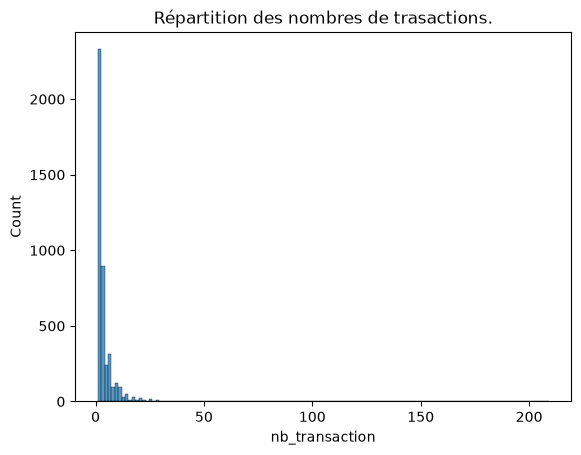

In [10]:
import seaborn as sns

sns.histplot(data, x="nb_transaction")
plt.title("Répartition des nombres de trasactions.")
plt.show()

On voit que la distribution n'est pas centré et par conséquent on va appliqué un logarithme.

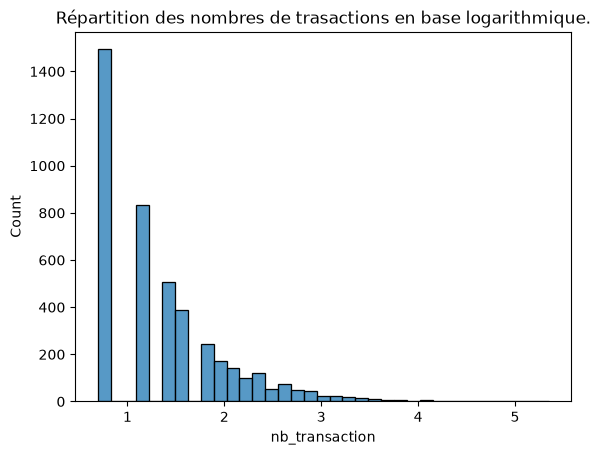

In [11]:
import numpy as np

sns.histplot(data, x=np.log1p(data["nb_transaction"]))
plt.title("Répartition des nombres de trasactions en base logarithmique.")
plt.show()

On observe que la distribution est maintenant centré. On voit que le nombre de clients diminue avec le nombre de transactions.

In [ ]:
data["nb_lignes_moyen_par_transactions"] = (
    df.groupby(["CustomerID", "InvoiceNo"])["StockCode"]
    .nunique()
    .groupby("CustomerID")
    .mean()
)
data

,nb_transaction,nb_lignes_moyen_par_transactions
CustomerID,,
12346.0,1,1.000000
12347.0,7,26.000000
12348.0,4,6.750000
12349.0,1,73.000000
12350.0,1,17.000000
...,...,...
18280.0,1,10.000000
18281.0,1,7.000000
18282.0,2,6.000000


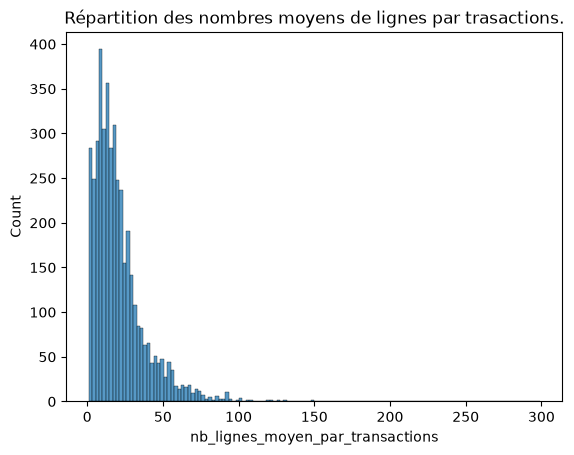

In [26]:
sns.histplot(data, x="nb_lignes_moyen_par_transactions")
plt.title("Répartition des nombres moyens de lignes par trasactions.")
plt.show()

On voit que la distribution n'est pas centré. Appliquons un logarithme.

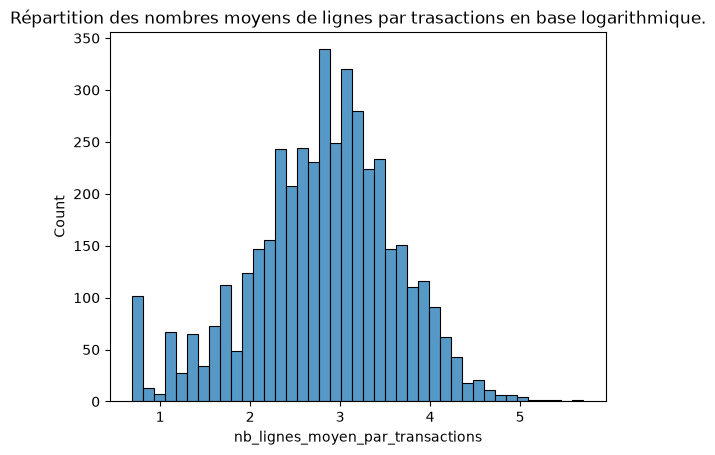

In [ ]:
sns.histplot(data, x=np.log1p(data["nb_lignes_moyen_par_transactions"]))
plt.title(
    "Répartition des nombres moyens de lignes par trasactions en base logarithmique."
)
plt.show()

On observe que cette variable suit une loi normale centré.